In [19]:
import pandas as pd
import matplotlib.pyplot as mp
import seaborn as sb
import os
from sklearn.cluster import KMeans
from sklearn import datasets
from sklearn.metrics import silhouette_score
from sklearn import decomposition
import warnings
warnings.filterwarnings("ignore")

os.chdir('/Users/miguel.vidal_ladivin/Documents/2da parte proyecto Ebas 2')

dataset = pd.read_csv("iris.csv")
dataset.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [31]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [21]:
fields = dataset.iloc[:,[0,2]].values
print(fields)

[[5.1 1.4]
 [4.9 1.4]
 [4.7 1.3]
 [4.6 1.5]
 [5.  1.4]
 [5.4 1.7]
 [4.6 1.4]
 [5.  1.5]
 [4.4 1.4]
 [4.9 1.5]
 [5.4 1.5]
 [4.8 1.6]
 [4.8 1.4]
 [4.3 1.1]
 [5.8 1.2]
 [5.7 1.5]
 [5.4 1.3]
 [5.1 1.4]
 [5.7 1.7]
 [5.1 1.5]
 [5.4 1.7]
 [5.1 1.5]
 [4.6 1. ]
 [5.1 1.7]
 [4.8 1.9]
 [5.  1.6]
 [5.  1.6]
 [5.2 1.5]
 [5.2 1.4]
 [4.7 1.6]
 [4.8 1.6]
 [5.4 1.5]
 [5.2 1.5]
 [5.5 1.4]
 [4.9 1.5]
 [5.  1.2]
 [5.5 1.3]
 [4.9 1.4]
 [4.4 1.3]
 [5.1 1.5]
 [5.  1.3]
 [4.5 1.3]
 [4.4 1.3]
 [5.  1.6]
 [5.1 1.9]
 [4.8 1.4]
 [5.1 1.6]
 [4.6 1.4]
 [5.3 1.5]
 [5.  1.4]
 [7.  4.7]
 [6.4 4.5]
 [6.9 4.9]
 [5.5 4. ]
 [6.5 4.6]
 [5.7 4.5]
 [6.3 4.7]
 [4.9 3.3]
 [6.6 4.6]
 [5.2 3.9]
 [5.  3.5]
 [5.9 4.2]
 [6.  4. ]
 [6.1 4.7]
 [5.6 3.6]
 [6.7 4.4]
 [5.6 4.5]
 [5.8 4.1]
 [6.2 4.5]
 [5.6 3.9]
 [5.9 4.8]
 [6.1 4. ]
 [6.3 4.9]
 [6.1 4.7]
 [6.4 4.3]
 [6.6 4.4]
 [6.8 4.8]
 [6.7 5. ]
 [6.  4.5]
 [5.7 3.5]
 [5.5 3.8]
 [5.5 3.7]
 [5.8 3.9]
 [6.  5.1]
 [5.4 4.5]
 [6.  4.5]
 [6.7 4.7]
 [6.3 4.4]
 [5.6 4.1]
 [5.5 4. ]
 [5.5 4.4]

In [23]:
wcss = []

for index in range (1,11):
    kmeans = KMeans(n_clusters = index, init = "k-means++", random_state = 2)
    kmeans.fit(fields)
    wcss.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS - las distancias al cuadradro')

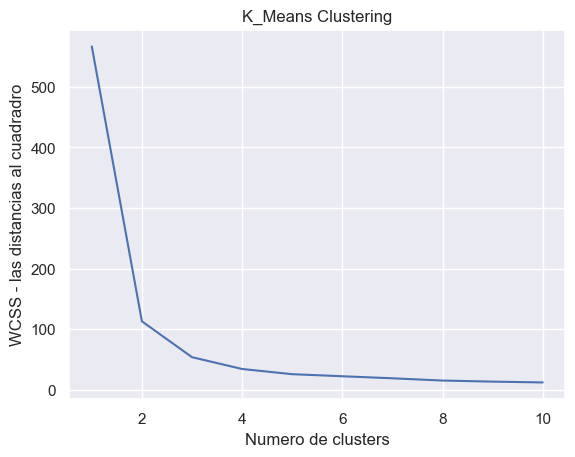

In [25]:
sb.set()
mp.plot(range(1,11),wcss)
mp.title("K_Means Clustering")
mp.xlabel("Numero de clusters")
mp.ylabel("WCSS - las distancias al cuadradro")

In [29]:
kmeans = KMeans(n_clusters = 3, init = "k-means++", random_state = 42)
cluster_values = kmeans.fit_predict(fields)
print(cluster_values)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 0 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


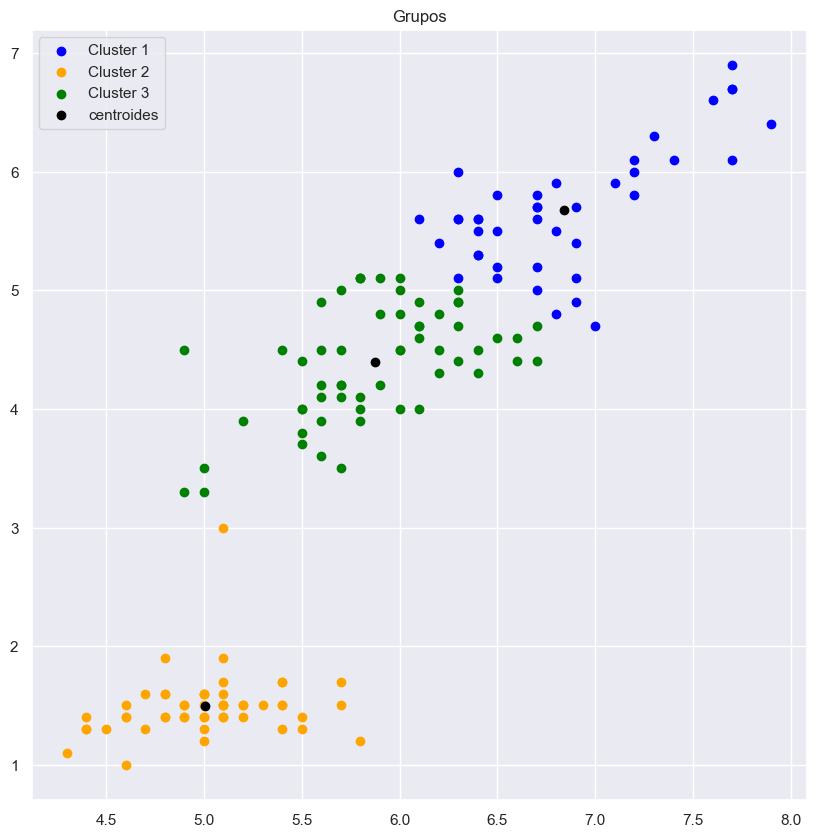

In [35]:
mp.figure(figsize=(10,10))
mp.scatter(fields[cluster_values==0,0], fields[cluster_values==0,1], c = "blue", label = "Cluster 1")
mp.scatter(fields[cluster_values==1,0], fields[cluster_values==1,1], c = "orange", label = "Cluster 2")
mp.scatter(fields[cluster_values==2,0], fields[cluster_values==2,1], c = "green", label = "Cluster 3")

mp.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c = "black", label = "centroides")

mp.title("Grupos")
mp.xlabel = "Sepal length"
mp.ylabel = "Sepal lenght"
mp.legend()

In [37]:
x = dataset.iloc[:,[0,2]].to_numpy()
for j in range (2,12):
    kmeans = KMeans(n_clusters = j , random_state = 42)
    kmeans.fit_predict(x)
    score = silhouette_score(x, kmeans.labels_, metric = "euclidean")
    print("Score SILHOUETTE", "K = ", j, ":", score)

Score SILHOUETTE K =  2 : 0.7097529826994815
Score SILHOUETTE K =  3 : 0.5890584158017611
Score SILHOUETTE K =  4 : 0.5645593160995663
Score SILHOUETTE K =  5 : 0.5577931215347036
Score SILHOUETTE K =  6 : 0.42674914186984686
Score SILHOUETTE K =  7 : 0.4101834218218532
Score SILHOUETTE K =  8 : 0.4152022022820345
Score SILHOUETTE K =  9 : 0.4170677437346434
Score SILHOUETTE K =  10 : 0.4103336064499661
Score SILHOUETTE K =  11 : 0.41316560218183823


In [51]:
fields2 = dataset.iloc[:,[0,1,2,3]].values
print(fields2)


[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [53]:
pca = decomposition.PCA (n_components = 2)
pca.fit(fields2)
fields2 = pca.transform(fields2)
fields2

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

In [59]:
wcss2 = []

for index in range (1,11):
    kmeans = KMeans(n_clusters = index, init = "k-means++", random_state = 2)
    kmeans.fit(fields2)
    wcss2.append(kmeans.inertia_)

TypeError: 'str' object is not callable

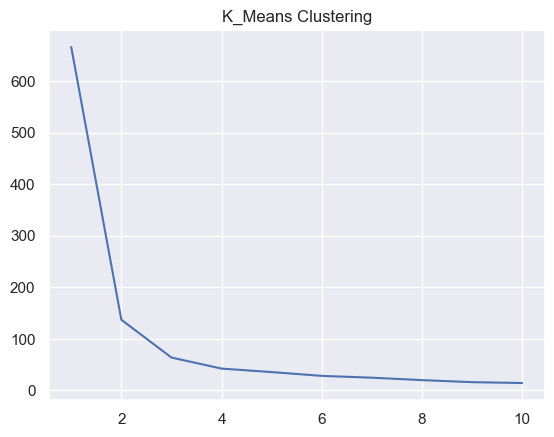

In [61]:
sb.set()
mp.plot(range(1,11),wcss2)
mp.title("K_Means Clustering")
mp.xlabel("Numero de clusters")
mp.ylabel("WCSS - las distancias al cuadradro")

In [63]:
kmeans = KMeans(n_clusters = 3, init = "k-means++", random_state = 42)
cluster_values = kmeans.fit_predict(fields2)
print(cluster_values)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


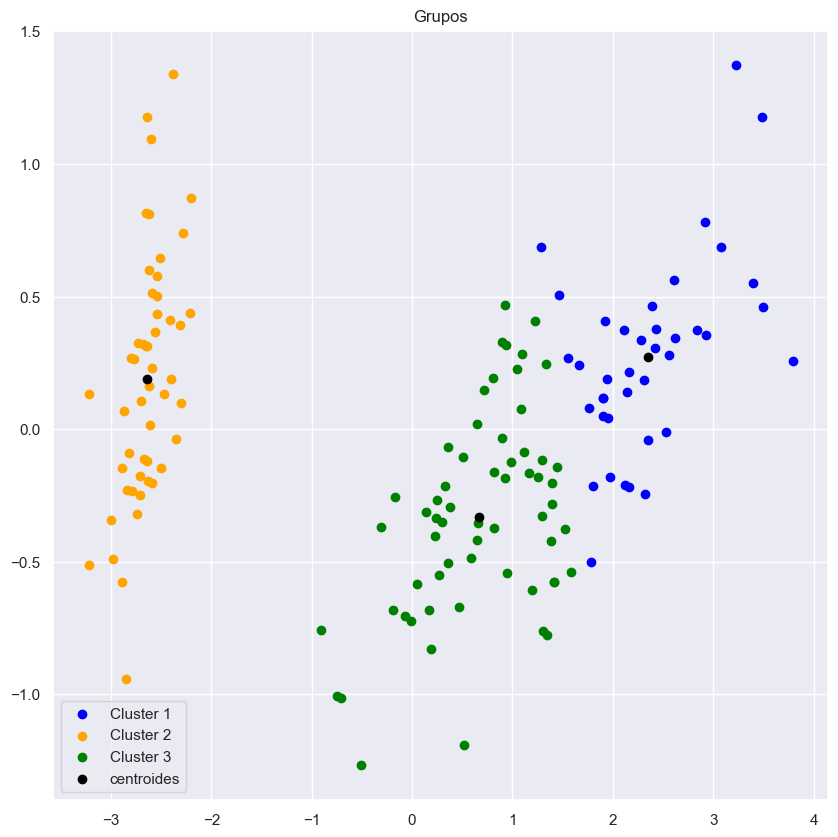

In [65]:
mp.figure(figsize=(10,10))
mp.scatter(fields2[cluster_values==0,0], fields2[cluster_values==0,1], c = "blue", label = "Cluster 1")
mp.scatter(fields2[cluster_values==1,0], fields2[cluster_values==1,1], c = "orange", label = "Cluster 2")
mp.scatter(fields2[cluster_values==2,0], fields2[cluster_values==2,1], c = "green", label = "Cluster 3")

mp.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c = "black", label = "centroides")

mp.title("Grupos")
mp.xlabel = "Sepal length"
mp.ylabel = "Sepal lenght"
mp.legend()